##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:
# Exercise 1: Unsupervised Clustering using DINOv2 CLS Tokens

import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms

from transformers import AutoImageProcessor, AutoModel

from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.stats import mode

In [2]:
# Set device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
# Load Oxford-IIIT Pet dataset
# binary-category gives cat/dog labels

dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="binary-category",
    download=True
)

print("Dataset size:", len(dataset))

100%|██████████| 792M/792M [00:03<00:00, 225MB/s]  
100%|██████████| 19.2M/19.2M [00:00<00:00, 112MB/s] 


Dataset size: 3680


In [4]:
# Select 10 cats and 10 dogs

cat_images = []
dog_images = []

for img, label in dataset:
    # In OxfordIIITPet binary-category:
    # label 0 = cat, label 1 = dog
    if label == 0 and len(cat_images) < 10:
        cat_images.append((img, label))
    elif label == 1 and len(dog_images) < 10:
        dog_images.append((img, label))

    if len(cat_images) == 10 and len(dog_images) == 10:
        break

selected_data = cat_images + dog_images

images = [item[0] for item in selected_data]
true_labels = np.array([item[1] for item in selected_data])

print("Number of selected images:", len(images))
print("True labels:", true_labels)

Number of selected images: 20
True labels: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


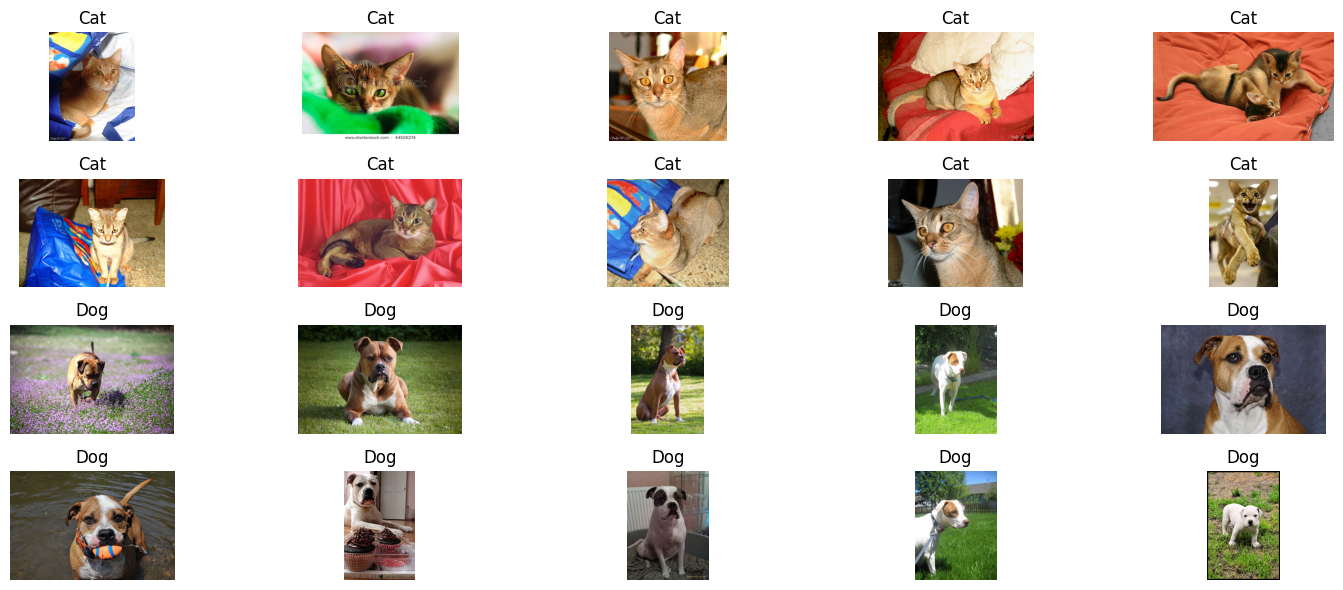

In [5]:
# Display selected images

plt.figure(figsize=(15, 6))

for i, img in enumerate(images):
    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    label_name = "Cat" if true_labels[i] == 0 else "Dog"
    plt.title(label_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Load DINOv2 model and processor

processor = AutoImageProcessor.from_pretrained("facebook/dinov2-small")
model = AutoModel.from_pretrained("facebook/dinov2-small").to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((384,), eps=1e-06,

In [7]:
# Extract 384-dimensional CLS tokens

cls_tokens = []

with torch.no_grad():
    for img in images:
        inputs = processor(images=img, return_tensors="pt").to(device)

        outputs = model(**inputs)

        # CLS token is the first token
        cls_token = outputs.last_hidden_state[:, 0, :]

        cls_tokens.append(cls_token.cpu().numpy().squeeze())

cls_tokens = np.array(cls_tokens)

print("CLS tokens shape:", cls_tokens.shape)

CLS tokens shape: (20, 384)


In [8]:
# Apply K-Means clustering with 2 clusters

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(cls_tokens)

print("Predicted cluster labels:", cluster_labels)

Predicted cluster labels: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


In [9]:
# Since KMeans cluster labels are arbitrary,
# map each cluster to the majority ground-truth label

mapped_labels = np.zeros_like(cluster_labels)

for cluster_id in np.unique(cluster_labels):
    indices = np.where(cluster_labels == cluster_id)[0]
    majority_label = mode(true_labels[indices], keepdims=True).mode[0]
    mapped_labels[indices] = majority_label

print("Mapped predicted labels:", mapped_labels)
print("True labels:            ", true_labels)

Mapped predicted labels: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
True labels:             [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


In [10]:
# Compare predicted clusters with ground-truth labels

accuracy = accuracy_score(true_labels, mapped_labels)

print("Clustering Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, mapped_labels))

print("\nClassification Report:")
print(classification_report(
    true_labels,
    mapped_labels,
    target_names=["Cat", "Dog"]
))

Clustering Accuracy: 1.0

Confusion Matrix:
[[10  0]
 [ 0 10]]

Classification Report:
              precision    recall  f1-score   support

         Cat       1.00      1.00      1.00        10
         Dog       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



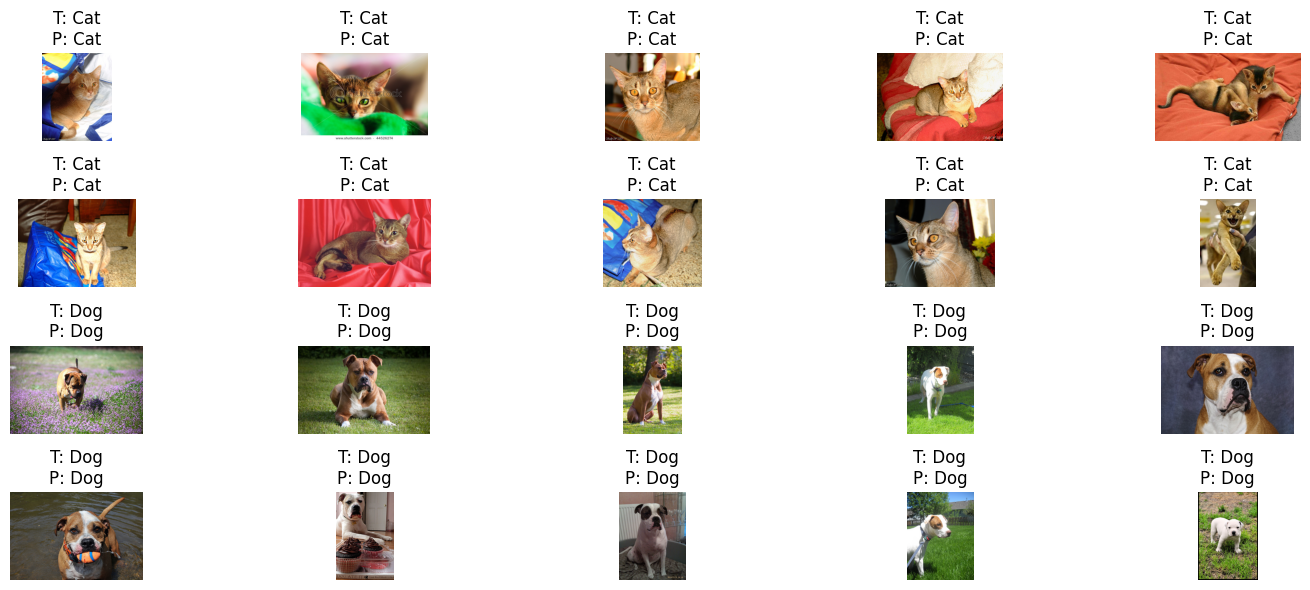

In [11]:
# Visualize clustering result

plt.figure(figsize=(15, 6))

for i, img in enumerate(images):
    plt.subplot(4, 5, i + 1)
    plt.imshow(img)

    true_name = "Cat" if true_labels[i] == 0 else "Dog"
    pred_name = "Cat" if mapped_labels[i] == 0 else "Dog"

    plt.title(f"T: {true_name}\nP: {pred_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [12]:
# Exercise 2: Image Classification with DINOv2

import torch
import requests
import matplotlib.pyplot as plt

from PIL import Image
from io import BytesIO
from transformers import AutoImageProcessor, AutoModelForImageClassification

In [13]:
# Set device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [14]:
# Model ID required by the exercise

model_id = "facebook/dinov2-small-imagenet1k-1-layer"

processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModelForImageClassification.from_pretrained(model_id).to(device)

model.eval()

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Dinov2ForImageClassification(
  (dinov2): Dinov2Model(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (attention): Dinov2Attention(
            (attention): Dinov2SelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (layer_scale1): Dinov2Laye

Status code: 200
Content type: image/jpeg


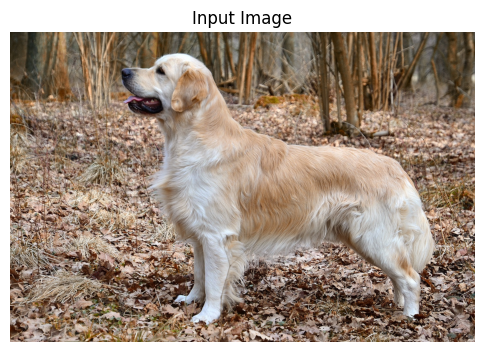

In [16]:
# Load an online image
# This image is a Golden Retriever, which is one of the ImageNet-1k classes

image_url = "https://upload.wikimedia.org/wikipedia/commons/9/93/Golden_Retriever_Carlos_%2810581910556%29.jpg"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(image_url, headers=headers)

print("Status code:", response.status_code)
print("Content type:", response.headers.get("Content-Type"))

if response.status_code != 200:
    raise Exception("Failed to download image. Try another image URL.")

if "image" not in response.headers.get("Content-Type", ""):
    raise Exception("The URL did not return an image file. Try another direct image URL.")

image = Image.open(BytesIO(response.content)).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [17]:
# Preprocess image and run inference

inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
predicted_class_idx = logits.argmax(-1).item()

predicted_label = model.config.id2label[predicted_class_idx]

print("Predicted class index:", predicted_class_idx)
print("Predicted label:", predicted_label)

Predicted class index: 207
Predicted label: golden retriever


In [18]:
# Show top-5 predictions

probabilities = torch.nn.functional.softmax(logits, dim=-1)
top5 = torch.topk(probabilities, k=5)

print("Top-5 Predictions:\n")

for score, class_idx in zip(top5.values[0], top5.indices[0]):
    label = model.config.id2label[class_idx.item()]
    confidence = score.item() * 100
    print(f"{label}: {confidence:.2f}%")

Top-5 Predictions:

golden retriever: 90.67%
Labrador retriever: 2.55%
clumber, clumber spaniel: 2.32%
English setter: 1.35%
Sussex spaniel: 0.51%


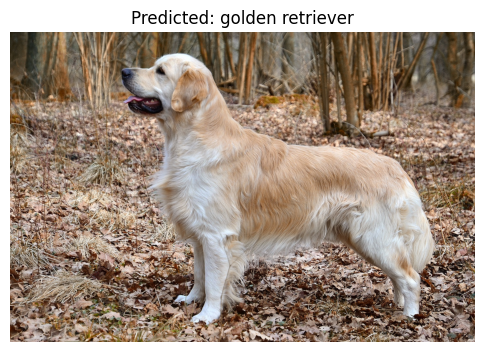

In [19]:
# Visualize prediction result

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"Predicted: {predicted_label}")
plt.show()